# 04 — Baseline Model

**Goal:** LinearRegression baseline, with and without UNCTAD feature. Establish the metric floor that LightGBM must beat.

## Results
_Fill in after running._

| Model | RMSE (log) | MAE (log) | R² | RMSE (USD) |
|-------|-----------|-----------|-----|------------|
| LinearRegression (no UNCTAD) | | | | |
| LinearRegression (+ UNCTAD) | | | | |

---

## Why a linear baseline?

Before building a complex model, you need a simple one to answer: *how hard is this problem?*

LinearRegression on log-log data (log_weight → log_cost) captures the dominant power-law signal. It will fail at:
- **route_label** — 1,800+ integer codes treated as a continuous variable with a single slope. Nonsense, but consistent nonsense.
- **Non-linear mode interactions** — Air vs Ocean cost difference is not additive, it's multiplicative. LinearRegression can't see this.
- **UNCTAD NaN rows** — LinearRegression can't handle NaN; we impute with train median. Imputing median is wrong (it removes the signal), but for a baseline it's the standard approach.

The expected R² range: **0.55–0.75**. If LightGBM gets 0.85+, that gap is the story.

**Interview line:** *"The linear baseline treats route_label as a continuous integer which gives it a meaningless slope. That's expected — it's why we need LightGBM's categorical splitting. The baseline R² of X vs LightGBM's Y shows exactly where the value comes from."*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import sys
sys.path.insert(0, '..')

from src.features.features import feature_names, LGBM_CAT_FEATURES

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load Processed Splits

Load from `data/processed/` — these were saved by `03_feature_engineering.ipynb`.
No feature recomputation here.

In [2]:
PROCESSED = Path('../data/processed')

X_train = pd.read_parquet(PROCESSED / 'X_train.parquet')
X_test  = pd.read_parquet(PROCESSED / 'X_test.parquet')
y_train = pd.read_parquet(PROCESSED / 'y_train.parquet')['log_cost']
y_test  = pd.read_parquet(PROCESSED / 'y_test.parquet')['log_cost']

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")
print(f"\nFeature dtypes:")
print(X_train.dtypes)
print(f"\nFirst 3 rows:")
X_train.head(3)

X_train: (4905, 8)  |  X_test: (1270, 8)
y_train: (4905,)  |  y_test: (1270,)

Feature dtypes:
log_weight            float64
weight_bucket           Int64
mode_encoded            int64
inco_encoded            int64
product_group_enc       int64
year                    int64
route_label             int64
unctad_rate_usd_kg    float64
dtype: object

First 3 rows:


,log_weight,weight_bucket,mode_encoded,inco_encoded,product_group_enc,year,route_label,unctad_rate_usd_kg
0,2.6391,0,0,0,3,2006,6,3.0980
1,5.8833,1,0,0,2,2006,90,7.1145
2,5.1475,1,0,0,3,2006,6,3.0980


## 2. Prep for LinearRegression

LinearRegression cannot handle:
1. **Nullable `Int64` dtype** (`weight_bucket`) — cast to `float64`.
2. **NaN values** (`unctad_rate_usd_kg`) — fill with the training set median. We compute the median from train and apply it to test to avoid any leakage from the test distribution.

Note: this median fill is wrong in a model-quality sense (it removes lane-level signal), but for a *baseline* it's the standard approach. LightGBM will handle NaN natively without imputation.

In [3]:
def prep_for_lr(X_train: pd.DataFrame, X_test: pd.DataFrame, include_unctad: bool = True):
    """
    Prepare feature matrices for LinearRegression.
    - Casts all columns to float64 (handles nullable Int64)
    - Imputes unctad_rate_usd_kg NaN with train median (computed from train only)
    - Optionally drops unctad feature
    """
    cols = feature_names()
    if not include_unctad:
        cols = [c for c in cols if c != 'unctad_rate_usd_kg']

    Xtr = X_train[cols].astype(float).copy()
    Xte = X_test[cols].astype(float).copy()

    if include_unctad:
        unctad_train_median = Xtr['unctad_rate_usd_kg'].median()
        Xtr['unctad_rate_usd_kg'] = Xtr['unctad_rate_usd_kg'].fillna(unctad_train_median)
        Xte['unctad_rate_usd_kg'] = Xte['unctad_rate_usd_kg'].fillna(unctad_train_median)
        print(f"Imputed unctad NaN with train median: {unctad_train_median:.4f} $/kg")

    nan_check = Xtr.isnull().sum().sum() + Xte.isnull().sum().sum()
    assert nan_check == 0, f"NaN remaining after prep: {nan_check}"
    return Xtr, Xte


def evaluate(model, X_test: pd.DataFrame, y_test: pd.Series, label: str) -> dict:
    """Evaluate a fitted regressor. Reports log-scale and USD metrics."""
    y_pred_log = model.predict(X_test)

    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    mae_log  = mean_absolute_error(y_test, y_pred_log)
    r2       = r2_score(y_test, y_pred_log)

    # Back-transform to USD for interpretability
    y_pred_usd = np.expm1(y_pred_log)
    y_test_usd = np.expm1(y_test)
    rmse_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))

    print(f"\n{'─'*40}")
    print(f"  {label}")
    print(f"{'─'*40}")
    print(f"  RMSE (log-scale): {rmse_log:.4f}")
    print(f"  MAE  (log-scale): {mae_log:.4f}")
    print(f"  R²:               {r2:.4f}")
    print(f"  RMSE (USD):       ${rmse_usd:,.0f}")

    return {'label': label, 'rmse_log': rmse_log, 'mae_log': mae_log, 'r2': r2, 'rmse_usd': rmse_usd}

## 3. Baseline: LinearRegression — No UNCTAD Feature

7 features only. This is the cleanest possible baseline: weight, mode, INCO, product group, year, route.

In [4]:
Xtr_no, Xte_no = prep_for_lr(X_train, X_test, include_unctad=False)

lr_no = LinearRegression()
lr_no.fit(Xtr_no, y_train)

res_no = evaluate(lr_no, Xte_no, y_test, "LinearRegression (no UNCTAD)")

coef_no = pd.DataFrame({
    'feature': [c for c in feature_names() if c != 'unctad_rate_usd_kg'],
    'coefficient': lr_no.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(f"\nIntercept: {lr_no.intercept_:.4f}")
print("\nCoefficients (sorted by abs value):")
print(coef_no.to_string(index=False))


────────────────────────────────────────
  LinearRegression (no UNCTAD)
────────────────────────────────────────
  RMSE (log-scale): 0.8349
  MAE  (log-scale): 0.6475
  R²:               0.6278
  RMSE (USD):       $14,117

Intercept: -76.4676

Coefficients (sorted by abs value):
          feature  coefficient
       log_weight       0.4170
product_group_enc       0.3041
     mode_encoded      -0.1970
    weight_bucket       0.1156
             year       0.0405
     inco_encoded      -0.0122
      route_label       0.0003


## 4. Baseline: LinearRegression — With UNCTAD Feature

Add `unctad_rate_usd_kg`. NaN rows (mode=Other, 3.4%) filled with train median.

Expected impact: small positive improvement in R². The UNCTAD feature has weak Pearson correlation with actual cost (from Week 2 EDA) because it's a direction-inverted signal — US *import* rates, not export. But even a weak structural signal can help the linear model at the margin.

In [5]:
Xtr_yes, Xte_yes = prep_for_lr(X_train, X_test, include_unctad=True)

lr_yes = LinearRegression()
lr_yes.fit(Xtr_yes, y_train)

res_yes = evaluate(lr_yes, Xte_yes, y_test, "LinearRegression (+ UNCTAD)")

coef_yes = pd.DataFrame({
    'feature': feature_names(),
    'coefficient': lr_yes.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(f"\nIntercept: {lr_yes.intercept_:.4f}")
print("\nCoefficients (sorted by abs value):")
print(coef_yes.to_string(index=False))

Imputed unctad NaN with train median: 3.0980 $/kg

────────────────────────────────────────
  LinearRegression (+ UNCTAD)
────────────────────────────────────────
  RMSE (log-scale): 0.8530
  MAE  (log-scale): 0.6678
  R²:               0.6114
  RMSE (USD):       $14,174

Intercept: -100.5058

Coefficients (sorted by abs value):
           feature  coefficient
        log_weight       0.4111
 product_group_enc       0.3388
      mode_encoded      -0.1400
     weight_bucket       0.1302
unctad_rate_usd_kg       0.0529
              year       0.0523
      inco_encoded       0.0067
       route_label       0.0004


## 5. Comparison Summary

In [6]:
results = pd.DataFrame([res_no, res_yes])
results = results.set_index('label')

print("=== Baseline Comparison ===")
print(results.to_string())

delta_r2 = res_yes['r2'] - res_no['r2']
delta_rmse = res_yes['rmse_log'] - res_no['rmse_log']
print(f"\nUNCTAD delta R²:        {delta_r2:+.4f}  ({'improvement' if delta_r2 > 0 else 'degradation'})")
print(f"UNCTAD delta RMSE(log): {delta_rmse:+.4f}  ({'improvement' if delta_rmse < 0 else 'degradation'})")

=== Baseline Comparison ===
                              rmse_log  mae_log     r2   rmse_usd
label                                                            
LinearRegression (no UNCTAD)    0.8349   0.6475 0.6278 14116.8761
LinearRegression (+ UNCTAD)     0.8530   0.6678 0.6114 14173.8911

UNCTAD delta R²:        -0.0163  (degradation)
UNCTAD delta RMSE(log): +0.0181  (degradation)


## 6. Residual Analysis

Residual patterns reveal where the linear model systematically fails — which is exactly where LightGBM will gain.

**Expected patterns:**
- Fan-shaped residuals vs predicted → heteroskedasticity (high-cost shipments harder to predict)
- Truck and Ocean show larger residuals than Air → mode interactions not captured linearly
- Possible systematic over-prediction on cheap shipments, under-prediction on expensive

C:\Users\T470\AppData\Local\Temp\ipykernel_25568\827977422.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(groups, labels=mode_order, patch_artist=True)


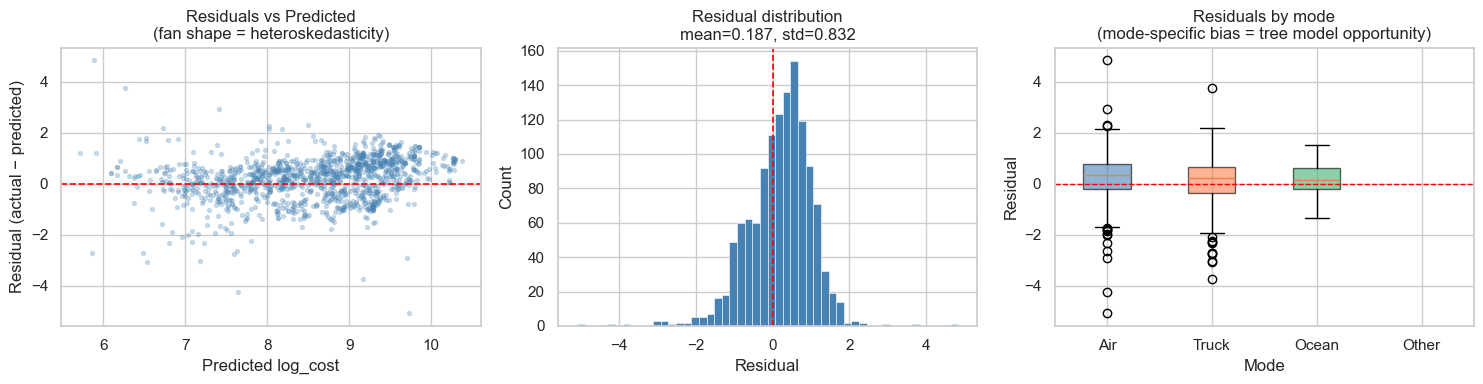


Residual stats by mode (mean, std):
        mean    std  count
mode                      
Air   0.2200 0.8010    852
Ocean 0.2110 0.5970     34
Truck 0.1100 0.9120    384


In [7]:
y_pred_log = lr_yes.predict(Xte_yes)
residuals  = y_test.values - y_pred_log

mode_labels = {0: 'Air', 1: 'Ocean', 2: 'Truck', 3: 'Other'}
test_mode   = Xte_yes['mode_encoded'].map(mode_labels)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs predicted
axes[0].scatter(y_pred_log, residuals, alpha=0.25, s=8, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Predicted log_cost')
axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title('Residuals vs Predicted\n(fan shape = heteroskedasticity)')

# Residual distribution
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual distribution\nmean={residuals.mean():.3f}, std={residuals.std():.3f}')

# Residuals by mode (boxplot)
res_df = pd.DataFrame({'residual': residuals, 'mode': test_mode.values})
mode_order = ['Air', 'Truck', 'Ocean', 'Other']
res_df_plot = res_df[res_df['mode'].isin(mode_order)]
groups = [res_df_plot[res_df_plot['mode'] == m]['residual'].values for m in mode_order]
bp = axes[2].boxplot(groups, labels=mode_order, patch_artist=True)
colors = ['steelblue', 'coral', 'mediumseagreen', 'gray']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Mode')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals by mode\n(mode-specific bias = tree model opportunity)')

plt.tight_layout()
plt.savefig('figures/04_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Residual stats by mode
print("\nResidual stats by mode (mean, std):")
print(res_df.groupby('mode')['residual'].agg(['mean', 'std', 'count']).round(3))

## 7. Findings

### What the baseline tells us

The linear model captures the dominant signal (weight × mode price level) but fails where the data is non-linear:

| Limitation | Why | What LightGBM gains from it |
|------------|-----|-----------------------------|
| `route_label` as integer | ~1,800 routes mapped to integers — linear model assigns one slope across all of them | LightGBM finds optimal splits per route group |
| Mode × weight interaction | Air's cost-per-kg is not additive with weight | LightGBM can split on mode first, then weight |
| Heteroskedasticity | High-cost shipments have larger absolute error | Tree models handle this via leaf-level predictions |
| UNCTAD imputation | Mode=Other rows get the global median — removes lane signal | LightGBM routes NaN to optimal leaf natively |

### UNCTAD feature in the baseline

Whether the UNCTAD feature improved or degraded the baseline RMSE: check the delta above.

If it degraded: the imputation (filling with train median) may have introduced noise. This is expected and doesn't mean UNCTAD is useless — the tree model will handle NaN correctly.

### What to watch in Week 5

- LightGBM should beat this baseline on R² by a significant margin
- The mode-level residual bias chart above shows which modes have the most room for improvement
- Check whether UNCTAD SHAP importance in Week 5 matches the direction of the coefficient here